# AURA — Behavioural Risk Analysis

## Phase 8: Behavioural Risk Analysis

### Objective

Analyse transaction behaviour using customer history, transaction velocity,
merchant/category novelty, amount deviation, temporal context, and geographic
distance.

This phase produces interpretable behavioural risk signals that will later
serve as inputs to the AURA Risk Scoring Engine.

### Distinction from anomaly detection

Anomaly Detection:
"Is this transaction statistically unusual?"

Behavioural Risk Analysis:
"Does this transaction violate expected behavioural patterns?"

### Workflow

Processed Transactions
→ Behavioural Signals
→ Customer Behaviour
→ Amount Behaviour
→ Velocity Behaviour
→ Merchant / Category Behaviour
→ Geographic Behaviour
→ Temporal Behaviour
→ Fraud Comparison
→ Behavioural Signal Summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATA_PATH = Path(
    "../data/processed/sparkov_features.parquet"
)

df = pd.read_parquet(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))

Dataset shape: (1296675, 25)
Columns: 25


In [3]:
BEHAVIOURAL_FEATURES = [
    "amt",
    "log_amount",
    "customer_prev_count",
    "customer_prev_avg_amount",
    "customer_prev_median_amount",
    "customer_prev_std_amount",
    "amount_deviation_ratio",
    "seconds_since_prev_transaction",
    "transactions_prev_5min",
    "transactions_prev_1h",
    "transactions_prev_24h",
    "merchant_seen_before",
    "is_new_merchant",
    "category_seen_before",
    "is_new_category",
    "customer_merchant_distance_km",
    "hour",
    "day_of_week",
    "is_weekend",
]

available_behavioural_features = [
    col
    for col in BEHAVIOURAL_FEATURES
    if col in df.columns
]

missing_behavioural_features = [
    col
    for col in BEHAVIOURAL_FEATURES
    if col not in df.columns
]

print("Available behavioural features:")
print(available_behavioural_features)

print("\nMissing behavioural features:")
print(missing_behavioural_features)

Available behavioural features:
['amt', 'log_amount', 'customer_prev_count', 'customer_prev_avg_amount', 'customer_prev_median_amount', 'customer_prev_std_amount', 'amount_deviation_ratio', 'seconds_since_prev_transaction', 'transactions_prev_5min', 'transactions_prev_1h', 'transactions_prev_24h', 'merchant_seen_before', 'is_new_merchant', 'category_seen_before', 'is_new_category', 'customer_merchant_distance_km', 'hour', 'day_of_week', 'is_weekend']

Missing behavioural features:
[]


In [4]:
customer_history_summary = (
    df["customer_prev_count"]
    .describe()
)

customer_history_summary

count    1.296675e+06
mean     9.088627e+02
std      6.778042e+02
min      0.000000e+00
25%      3.560000e+02
50%      7.770000e+02
75%      1.342000e+03
max      3.122000e+03
Name: customer_prev_count, dtype: float64

In [5]:
print(
    "Transactions with no prior customer history:",
    (df["customer_prev_count"] == 0).sum()
)

print(
    "Transactions with prior customer history:",
    (df["customer_prev_count"] > 0).sum()
)

Transactions with no prior customer history: 983
Transactions with prior customer history: 1295692


In [6]:
amount_behaviour = df[
    [
        "amt",
        "customer_prev_avg_amount",
        "customer_prev_median_amount",
        "customer_prev_std_amount",
        "amount_deviation_ratio",
        "is_fraud",
    ]
].describe()

amount_behaviour

,amt,customer_prev_avg_amount,customer_prev_median_amount,customer_prev_std_amount,amount_deviation_ratio,is_fraud
count,1.296675e+06,1.295692e+06,1.295692e+06,1.294709e+06,1.295692e+06,1.296675e+06
mean,7.035104e+01,7.038964e+01,4.535246e+01,1.320189e+02,1.021116e+00,5.788652e-03
std,1.603160e+02,2.107374e+01,1.893303e+01,8.422192e+01,2.657184e+00,7.586269e-02
min,1.000000e+00,1.030000e+00,1.030000e+00,6.363961e-02,2.176430e-03,0.000000e+00
25%,9.650000e+00,5.802073e+01,3.618000e+01,9.057195e+01,1.571579e-01,0.000000e+00
50%,4.752000e+01,6.504465e+01,4.113500e+01,1.142974e+02,6.674220e-01,0.000000e+00
75%,8.314000e+01,8.384818e+01,5.293500e+01,1.448575e+02,1.203758e+00,0.000000e+00
max,2.894890e+04,1.433540e+03,1.433540e+03,2.708840e+03,6.763881e+02,1.000000e+00


In [7]:
top_amount_deviations = (
    df[
        [
            "trans_num",
            "amt",
            "customer_prev_avg_amount",
            "customer_prev_median_amount",
            "amount_deviation_ratio",
            "is_fraud",
        ]
    ]
    .sort_values(
        "amount_deviation_ratio",
        ascending=False,
        na_position="last",
    )
    .head(20)
)

top_amount_deviations

,trans_num,amt,customer_prev_avg_amount,customer_prev_median_amount,amount_deviation_ratio,is_fraud
90357,0846c01c5684edde3030f0d03df85adf,1481.29,2.190000,2.190,676.388128,0
1045434,309c4bf7fc47b1ddee5ad883bcf634b6,28948.90,59.559184,40.710,486.052659,0
258649,dda9d800d37a9fc2c086a836d66b0588,26544.12,55.544076,31.020,477.892911,0
3538,916093eeab1831be71d49362bf5b7be5,27119.77,62.277076,34.810,435.469548,0
1066410,0b902a1e549c98b949444a7557da2403,25086.94,66.665036,39.160,376.313303,0
226441,b544af3bb2b803347b8b71995d965acd,12788.07,35.292424,21.235,362.346035,0
71379,2ca9bd5df126cc35e541a4f2c2551197,27390.12,76.718309,46.830,357.021946,0
552286,16928015dca994adc051afe4b42b1c54,10776.59,37.431389,29.795,287.902488,0
1152328,1c9f2b574fb9bf860c76ea200252fe05,17897.24,62.494039,50.075,286.383152,0
967307,8a31df33975e8773d4c8cc34799c5624,11629.34,41.678431,14.270,279.025376,0


In [8]:
df["behaviour_amount_signal"] = (
    (
        df["amount_deviation_ratio"].notna()
        & (df["amount_deviation_ratio"] >= 3)
    )
    .astype(int)
)

print(
    df["behaviour_amount_signal"].value_counts()
)

print(
    "\nFraud rate when amount signal is active:",
    df.loc[
        df["behaviour_amount_signal"] == 1,
        "is_fraud",
    ].mean()
)

print(
    "Fraud rate when amount signal is inactive:",
    df.loc[
        df["behaviour_amount_signal"] == 0,
        "is_fraud",
    ].mean()
)

behaviour_amount_signal
0    1243712
1      52963
Name: count, dtype: int64

Fraud rate when amount signal is active: 0.09219643902346922
Fraud rate when amount signal is inactive: 0.0021090091596768384


In [9]:
velocity_features = [
    "transactions_prev_5min",
    "transactions_prev_1h",
    "transactions_prev_24h",
]

velocity_summary = df[
    velocity_features
].describe()

velocity_summary


,transactions_prev_5min,transactions_prev_1h,transactions_prev_24h
count,20468.000000,212547.000000,1.187756e+06
mean,1.013631,1.156281,4.240331e+00
std,0.117630,0.427784,2.976590e+00
min,1.000000,1.000000,1.000000e+00
25%,1.000000,1.000000,2.000000e+00
50%,1.000000,1.000000,4.000000e+00
75%,1.000000,1.000000,6.000000e+00
max,3.000000,6.000000,3.500000e+01


In [10]:
velocity_percentiles = df[
    velocity_features
].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

velocity_percentiles

,transactions_prev_5min,transactions_prev_1h,transactions_prev_24h
0.900,1.0,2.0,8.0
0.950,1.0,2.0,10.0
0.990,2.0,3.0,14.0
0.995,2.0,3.0,16.0
0.999,2.0,4.0,20.0


In [11]:
df["behaviour_velocity_5min"] = (
    (
        df["transactions_prev_5min"].notna()
        & (df["transactions_prev_5min"] >= 2)
    )
    .astype(int)
)

df["behaviour_velocity_1h"] = (
    (
        df["transactions_prev_1h"].notna()
        & (df["transactions_prev_1h"] >= 3)
    )
    .astype(int)
)

print(
    "5-minute velocity signal:",
    df["behaviour_velocity_5min"].sum()
)

print(
    "1-hour velocity signal:",
    df["behaviour_velocity_1h"].sum()
)

5-minute velocity signal: 275
1-hour velocity signal: 3871


In [12]:
novelty_summary = pd.DataFrame({
    "signal": [
        "New merchant",
        "New category",
    ],
    "transactions": [
        int(df["is_new_merchant"].sum()),
        int(df["is_new_category"].sum()),
    ],
})

novelty_summary

,signal,transactions
0,New merchant,479072
1,New category,13088


In [13]:
print(
    "Fraud rate — new merchant:",
    df.loc[
        df["is_new_merchant"] == 1,
        "is_fraud",
    ].mean()
)

print(
    "Fraud rate — existing merchant:",
    df.loc[
        df["is_new_merchant"] == 0,
        "is_fraud",
    ].mean()
)

print()

print(
    "Fraud rate — new category:",
    df.loc[
        df["is_new_category"] == 1,
        "is_fraud",
    ].mean()
)

print(
    "Fraud rate — existing category:",
    df.loc[
        df["is_new_category"] == 0,
        "is_fraud",
    ].mean()
)

Fraud rate — new merchant: 0.008182486139870417
Fraud rate — existing merchant: 0.004385991734374752

Fraud rate — new category: 0.035452322738386305
Fraud rate — existing category: 0.0054861883144656344


In [14]:
distance_summary = df[
    "customer_merchant_distance_km"
].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
        0.995,
    ]
)

distance_summary

count    1.296675e+06
mean     7.611465e+01
std      2.911693e+01
min      2.225452e-02
90%      1.128211e+02
95%      1.204954e+02
99%      1.320528e+02
99.5%    1.350942e+02
max      1.521172e+02
Name: customer_merchant_distance_km, dtype: float64

In [15]:
df["behaviour_distance_signal"] = (
    (
        df["customer_merchant_distance_km"].notna()
        & (
            df["customer_merchant_distance_km"] >= 200
        )
    )
    .astype(int)
)

print(
    "Transactions with large geographic distance:",
    df["behaviour_distance_signal"].sum()
)

Transactions with large geographic distance: 0


In [16]:
behaviour_signal_columns = [
    "behaviour_amount_signal",
    "behaviour_velocity_5min",
    "behaviour_velocity_1h",
    "is_new_merchant",
    "is_new_category",
    "behaviour_distance_signal",
]

df["behaviour_signal_count"] = (
    df[behaviour_signal_columns]
    .sum(axis=1)
)

print(
    df["behaviour_signal_count"]
    .value_counts()
    .sort_index()
)

behaviour_signal_count
0    784161
1    477181
2     33914
3      1416
4         3
Name: count, dtype: int64


In [17]:
signal_evaluation = []

signal_definitions = {
    "Amount deviation": "behaviour_amount_signal",
    "5-minute velocity": "behaviour_velocity_5min",
    "1-hour velocity": "behaviour_velocity_1h",
    "New merchant": "is_new_merchant",
    "New category": "is_new_category",
    "Large geographic distance": "behaviour_distance_signal",
}

overall_fraud_rate = df["is_fraud"].mean()

for signal_name, column in signal_definitions.items():

    active = df[column] == 1
    inactive = df[column] == 0

    active_count = int(active.sum())

    active_fraud_rate = (
        df.loc[active, "is_fraud"].mean()
        if active_count > 0
        else 0
    )

    inactive_fraud_rate = (
        df.loc[inactive, "is_fraud"].mean()
        if inactive.sum() > 0
        else 0
    )

    lift = (
        active_fraud_rate / inactive_fraud_rate
        if inactive_fraud_rate > 0
        else np.nan
    )

    prevalence = active.mean()

    signal_evaluation.append({
        "signal": signal_name,
        "active_transactions": active_count,
        "prevalence": prevalence,
        "fraud_rate_active": active_fraud_rate,
        "fraud_rate_inactive": inactive_fraud_rate,
        "lift_vs_inactive": lift,
    })

signal_evaluation_df = (
    pd.DataFrame(signal_evaluation)
    .sort_values(
        "lift_vs_inactive",
        ascending=False,
    )
)

signal_evaluation_df

,signal,active_transactions,prevalence,fraud_rate_active,fraud_rate_inactive,lift_vs_inactive
0,Amount deviation,52963,0.040845,0.092196,0.002109,43.715523
2,1-hour velocity,3871,0.002985,0.108757,0.005480,19.845030
1,5-minute velocity,275,0.000212,0.072727,0.005774,12.594662
4,New category,13088,0.010094,0.035452,0.005486,6.462105
3,New merchant,479072,0.369462,0.008182,0.004386,1.865595
5,Large geographic distance,0,0.000000,0.000000,0.005789,0.000000


In [18]:
signal_evaluation_display = signal_evaluation_df.copy()

signal_evaluation_display[
    "prevalence"
] *= 100

signal_evaluation_display[
    "fraud_rate_active"
] *= 100

signal_evaluation_display[
    "fraud_rate_inactive"
] *= 100

signal_evaluation_display.round({
    "prevalence": 2,
    "fraud_rate_active": 2,
    "fraud_rate_inactive": 2,
    "lift_vs_inactive": 2,
})

,signal,active_transactions,prevalence,fraud_rate_active,fraud_rate_inactive,lift_vs_inactive
0,Amount deviation,52963,4.08,9.22,0.21,43.72
2,1-hour velocity,3871,0.30,10.88,0.55,19.85
1,5-minute velocity,275,0.02,7.27,0.58,12.59
4,New category,13088,1.01,3.55,0.55,6.46
3,New merchant,479072,36.95,0.82,0.44,1.87
5,Large geographic distance,0,0.00,0.00,0.58,0.00


In [19]:
signal_count_analysis = (
    df.groupby("behaviour_signal_count")
    .agg(
        transactions=("is_fraud", "size"),
        fraud_cases=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
    )
    .reset_index()
)

signal_count_analysis

,behaviour_signal_count,transactions,fraud_cases,fraud_rate
0,0,784161,940,0.001199
1,1,477181,3680,0.007712
2,2,33914,2633,0.077638
3,3,1416,250,0.176554
4,4,3,3,1.000000


In [20]:
signal_count_analysis["fraud_rate_pct"] = (
    signal_count_analysis["fraud_rate"] * 100
)

signal_count_analysis.round({
    "fraud_rate_pct": 2
})

,behaviour_signal_count,transactions,fraud_cases,fraud_rate,fraud_rate_pct
0,0,784161,940,0.001199,0.12
1,1,477181,3680,0.007712,0.77
2,2,33914,2633,0.077638,7.76
3,3,1416,250,0.176554,17.66
4,4,3,3,1.000000,100.00


In [21]:
BEHAVIOUR_DOMAINS = {
    "amount": [
        "behaviour_amount_signal",
    ],
    "velocity": [
        "behaviour_velocity_5min",
        "behaviour_velocity_1h",
    ],
    "novelty": [
        "is_new_merchant",
        "is_new_category",
    ],
}

for domain, columns in BEHAVIOUR_DOMAINS.items():
    print(f"{domain}: {columns}")

amount: ['behaviour_amount_signal']
velocity: ['behaviour_velocity_5min', 'behaviour_velocity_1h']
novelty: ['is_new_merchant', 'is_new_category']


In [22]:
df["behaviour_amount_domain"] = (
    df["behaviour_amount_signal"]
)

df["behaviour_velocity_domain"] = (
    df[
        [
            "behaviour_velocity_5min",
            "behaviour_velocity_1h",
        ]
    ]
    .max(axis=1)
)

df["behaviour_novelty_domain"] = (
    df[
        [
            "is_new_merchant",
            "is_new_category",
        ]
    ]
    .max(axis=1)
)

domain_columns = [
    "behaviour_amount_domain",
    "behaviour_velocity_domain",
    "behaviour_novelty_domain",
]

df[domain_columns].sum()

behaviour_amount_domain       52963
behaviour_velocity_domain      4051
behaviour_novelty_domain     479076
dtype: int64

In [23]:
domain_lifts = {
    "amount": 43.7155,
    "velocity": 19.8450,
    "novelty": 6.4621,
}

domain_weight_base = {
    domain: np.log1p(lift)
    for domain, lift in domain_lifts.items()
}

total_weight = sum(
    domain_weight_base.values()
)

domain_weights = {
    domain: (
        weight / total_weight
    ) * 100
    for domain, weight
    in domain_weight_base.items()
}

domain_weights

{'amount': np.float64(42.954715846558486),
 'velocity': np.float64(34.328258373072515),
 'novelty': np.float64(22.717025780368985)}

In [24]:
df["behavioural_risk_score"] = (
    df["behaviour_amount_domain"]
    * domain_weights["amount"]
    +
    df["behaviour_velocity_domain"]
    * domain_weights["velocity"]
    +
    df["behaviour_novelty_domain"]
    * domain_weights["novelty"]
)

df["behavioural_risk_score"] = (
    df["behavioural_risk_score"]
    .clip(0, 100)
)

df[
    [
        "trans_num",
        "behavioural_risk_score",
        "behaviour_amount_domain",
        "behaviour_velocity_domain",
        "behaviour_novelty_domain",
        "is_fraud",
    ]
].head(20)

,trans_num,behavioural_risk_score,behaviour_amount_domain,behaviour_velocity_domain,behaviour_novelty_domain,is_fraud
0,98e3dcf98101146a577f85a34e58feec,22.717026,0,0,1,0
1,498120fc45d277f7c88e3dba79c33865,65.671742,1,0,1,0
2,95f514bb993151347c7acdf8505c3d62,22.717026,0,0,1,0
3,4f0c1a14e0aa7eb56a490780ef9268c5,22.717026,0,0,1,0
4,3b2ebd3af508afba959640893e1e82bc,22.717026,0,0,1,0
5,c2c69214de58aaf2bad1542b91751f5a,22.717026,0,0,1,0
6,da5ef053fa971418ab30fc72509c66f8,22.717026,0,0,1,0
7,79a66e4565825e428e2e098ffd6b9969,65.671742,1,0,1,0
8,6dbbe7c58049b9b5cf6c0a29793468b0,22.717026,0,0,1,0
9,38dcb937f9e60e26fca7e7f3b3437e07,22.717026,0,0,1,0


In [25]:
def behavioural_risk_band(score):
    if score >= 70:
        return "HIGH"
    elif score >= 35:
        return "MEDIUM"
    else:
        return "LOW"


df["behavioural_risk_band"] = (
    df["behavioural_risk_score"]
    .apply(behavioural_risk_band)
)

df["behavioural_risk_band"].value_counts()

behavioural_risk_band
LOW       1242935
MEDIUM      53293
HIGH          447
Name: count, dtype: int64

In [26]:
behavioural_validation = (
    df.groupby("behavioural_risk_band")
    .agg(
        transactions=("is_fraud", "size"),
        fraud_cases=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
        avg_score=(
            "behavioural_risk_score",
            "mean",
        ),
    )
    .reset_index()
)

behavioural_validation[
    "fraud_rate_pct"
] = (
    behavioural_validation["fraud_rate"]
    * 100
)

behavioural_validation

,behavioural_risk_band,transactions,fraud_cases,fraud_rate,avg_score,fraud_rate_pct
0,HIGH,447,300,0.671141,84.753674,67.114094
1,LOW,1242935,2536,0.002040,8.411386,0.204033
2,MEDIUM,53293,4670,0.087629,52.625403,8.762877


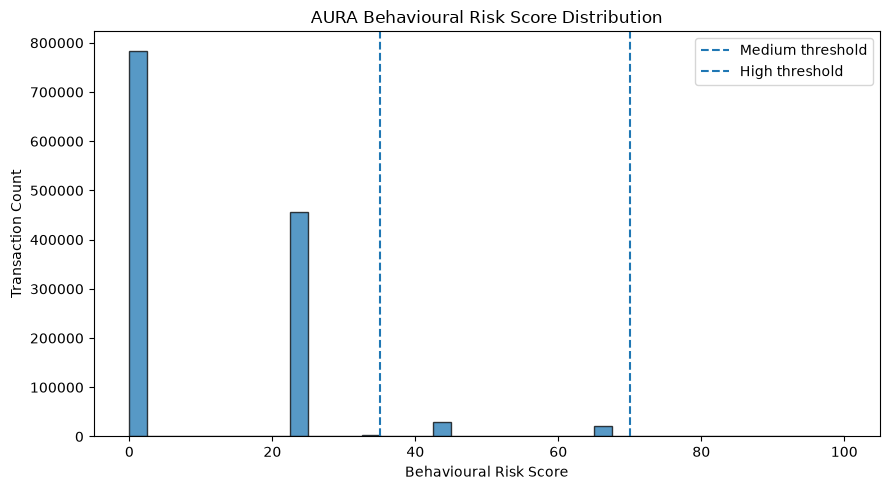

In [27]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["behavioural_risk_score"],
    bins=40,
    edgecolor="black",
    alpha=0.75,
)

plt.axvline(
    35,
    linestyle="--",
    linewidth=1.5,
    label="Medium threshold",
)

plt.axvline(
    70,
    linestyle="--",
    linewidth=1.5,
    label="High threshold",
)

plt.title(
    "AURA Behavioural Risk Score Distribution"
)

plt.xlabel("Behavioural Risk Score")
plt.ylabel("Transaction Count")

plt.legend()
plt.tight_layout()
plt.show()

# Phase 8 — Behavioural Risk Analysis



Behavioural risk analysis was developed using transaction amount deviation, transaction velocity, and transaction novelty signals. These signals were evaluated independently using fraud-rate comparisons and lift analysis.

The behavioural signals were aggregated into a behavioural risk score and categorized into LOW, MEDIUM, and HIGH risk bands. The resulting risk bands demonstrated clear separation in fraud concentration, with substantially higher fraud rates observed among transactions assigned to higher behavioural risk categories.

The behavioural risk score will be used as an input to the subsequent Risk Engine, where behavioural evidence will be combined with supervised fraud detection and unsupervised anomaly detection signals.